## Homework 4 | Nazira Tukeyeva

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import calendar
from sklearn.metrics import mean_absolute_error

### Data overview

In [82]:
df = pd.read_csv('wisla.csv')
df.head()

,stationid,name,water,hyear,hmonth,day,level,month
0,149180140,WISŁA,Wisła (2),1981,1,1,114,11
1,149180140,WISŁA,Wisła (2),1981,1,2,114,11
2,149180140,WISŁA,Wisła (2),1981,1,3,114,11
3,149180140,WISŁA,Wisła (2),1981,1,4,114,11
4,149180140,WISŁA,Wisła (2),1981,1,5,113,11


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15340 entries, 0 to 15339
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   stationid  15340 non-null  int64 
 1   name       15340 non-null  object
 2   water      15340 non-null  object
 3   hyear      15340 non-null  int64 
 4   hmonth     15340 non-null  int64 
 5   day        15340 non-null  int64 
 6   level      15340 non-null  int64 
 7   month      15340 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 958.9+ KB


In [84]:
print(df.name.unique())
print(df.water.unique())

['WISŁA']
['Wisła (2)']


In [85]:
df.shape

(15340, 8)

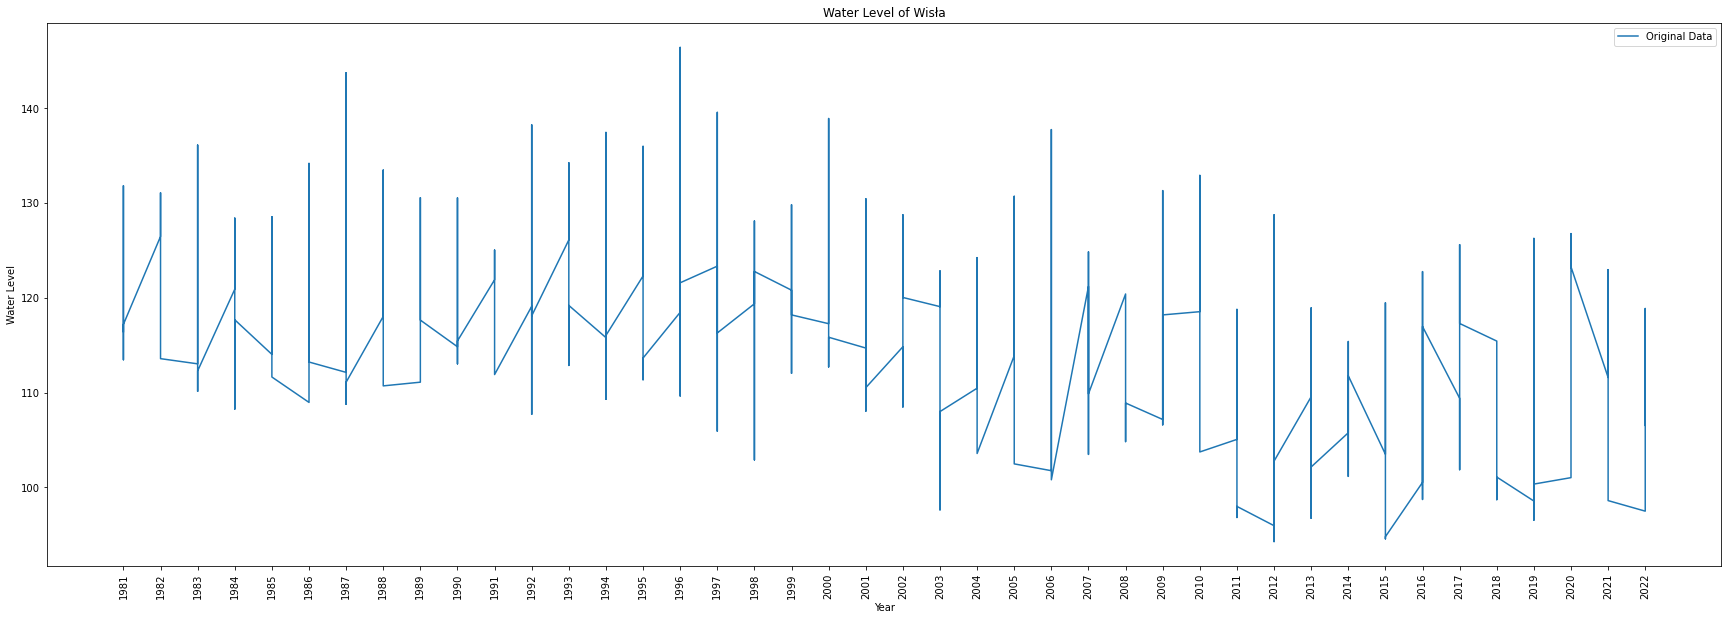

In [87]:
monthly_data = df.groupby(['hyear', 'hmonth'])['level'].mean()

plt.figure(figsize=(30, 10))
plt.plot([str(year) for year, month in monthly_data.index], monthly_data.values, label='Original Data')
plt.title('Water Level of Wisła')
plt.xlabel('Year')
plt.ylabel('Water Level')
plt.xticks(rotation=90) 
plt.legend()
plt.show()

This plot shows the water level of Wisla from 1981 up to 2022. This is a general plot as we can't see the exact distribution of water level by each month in each of the given years. However, from this plot we can clearly identify the year, when the level of water in the river reached its highests level (1996), while the lowest level of the water was reached in 2012/2015. Next on, I'll perform a more detailed analysis

### Trend & Seasonality

In [80]:
# df = df.drop(df[(df['month'] == 2) & (df['day'] == 29) & ~(df['hyear'] % 4 == 0)].index)
# df['Date'] = df[['hyear', 'month', 'day']].astype(str).apply('-'.join, axis=1)
# df['Date'] = pd.to_datetime(df['Date'])
# time_series = pd.Series(df['level'].values, index=df['Date'])

# regular month
#plt.figure(figsize=(12, 6))
#plt.plot(time_series)
#plt.title('Water Level of Wisła River Over Time')
#plt.xlabel('Date')
#plt.ylabel('Water Level')
#plt.grid(True)
#plt.show()

In [89]:
dateCheck = df['day'] <= df.apply(lambda row: calendar.monthrange(row['hyear'], row['hmonth'])[1], axis=1)
df = df[dateCheck]
df['Date'] = df[['hyear', 'hmonth', 'day']].astype(str).apply('-'.join, axis=1) # new colunm: Date
df['Date'] = pd.to_datetime(df['Date'])

time_series = pd.Series(df['level'].values, index=df['Date'])

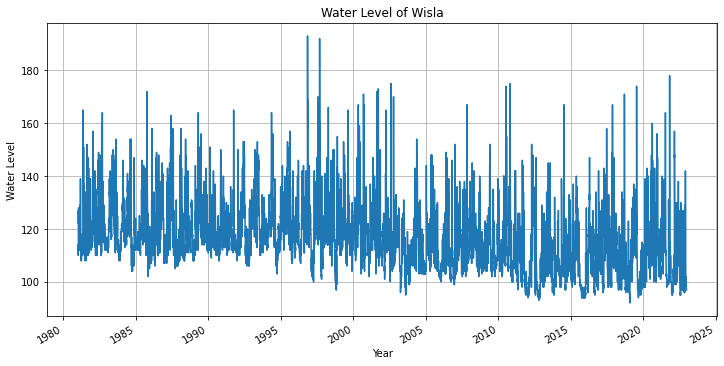

In [91]:
plt.figure(figsize=(12, 6))
time_series.plot()
plt.xlabel('Year')
plt.ylabel('Water Level')
plt.title('Water Level of Wisla')
plt.grid(True)
plt.show()

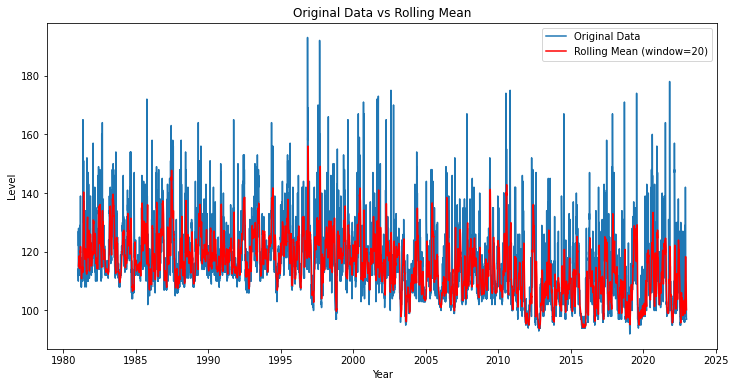

In [98]:
rolling_mean = time_series.rolling(window=20).mean()

plt.figure(figsize=(12, 6))
plt.plot(time_series, label='Original Data')
plt.plot(rolling_mean, color='red', label='Rolling Mean (window=20)')
plt.title('Original Data vs Rolling Mean')
plt.xlabel('Year')
plt.ylabel('Level')
plt.legend()
plt.show()

In the plot above we have original data vs data with moving average/window mean. As can be seen, our original data tend to have high volatility or so-called noise, which makes it difficult to identify the trend or seasonality clearly. By having the moving average, I was able to smooth out the fluctuations present in original data to be able to identify the patterns (trend/seasonality). Next on, I'll perform seasonal decomposition to better describe data and make appropriate conclusions about trend and seasonality in my dataset.

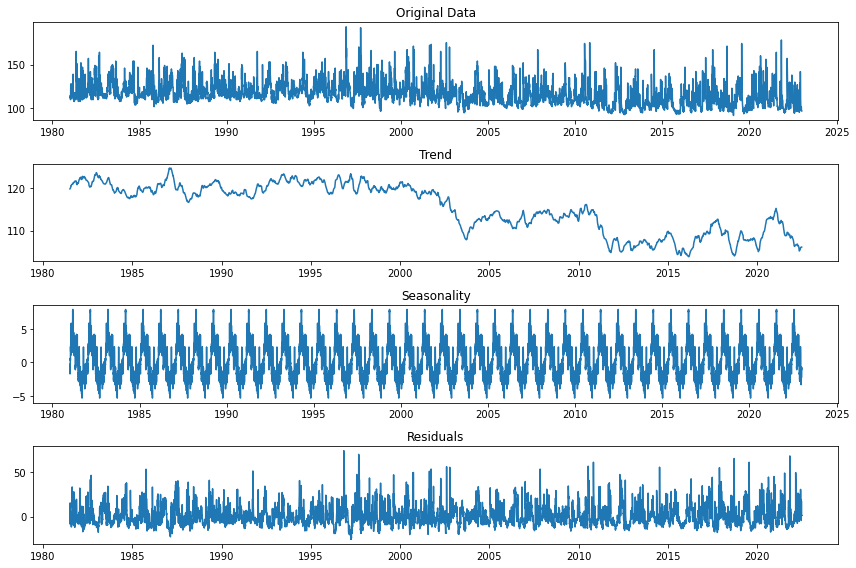

In [94]:
decomposition = seasonal_decompose(time_series, model='additive', period=365)

plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(time_series, label='Original Data')
plt.title('Original Data')
plt.subplot(4, 1, 2)
plt.plot(decomposition.trend, label='Trend')
plt.title('Trend')
plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.title('Seasonality')
plt.subplot(4, 1, 4)
plt.plot(decomposition.resid, label='Residuals')
plt.title('Residuals')
plt.tight_layout()
plt.show()

Some conclusions from the plots above regarding water level:

    1. While for most of the time, i.e. from 1981 to 2003 water level in Wisla remains at around the same high level, there is still a visible drop after 2003. This indicates a decrease in overall water levels over time, with the lowest water level being reached between 2015 and 2020. 

    2. From the seasonality plot we can clearly see that there are regular seasonal variations in the data that repeat over a period of time.

    3. By looking at residuals plot, I may conclude that there's some variability in data. 

In [99]:
adf = adfuller(time_series.dropna())
print('ADF Statistic:', adf[0])
print('p-value:', adf[1])
print('critical vals:')
for key, value in adf[4].items():
    print(f'  {key}: {value}')

ADF Statistic: -15.178664192147362
p-value: 6.242368931290044e-28
critical vals:
  1%: -3.430781254593382
  5%: -2.8617305960273764
  10%: -2.5668714496384633


To check the stationarity, I performed ADF test. The results shown above tell us that we have strong evidence for stationarity in data. Some conclusions:

    1. ADF Statistic value is -15.18. The more negative this value, the stronger the evidence of stationarity.

    2. p-value value is very close to 0 meaning that the probability of obtaining such (or even more) extreme results is extremely small*. So we reject H0.
    * provided that the null hypothesis H0 is true (that the data has a unit root and is NON-stationary).
    
    3. Critical values are given for different significance levels (1%, 5% and 10%). The value of the ADF statistic is less than all these critical values, which confirms the stationarity of our time series.

### ARMA

In [100]:
train_size = int(len(time_series) * 0.8)
train_data = time_series[:train_size]
test_data = time_series[train_size:]

In [102]:
print(train_data.shape)
print(test_data.shape)

(12145,)
(3037,)


In [109]:
from pmdarima import auto_arima

bestArma = auto_arima(train_data, seasonal=False, stepwise=True, suppress_warnings=True)

arma = sm.tsa.ARIMA(train_data, order=bestArma.order)
armaFit = arma.fit()

forecast = armaFit.forecast(steps=len(test_data))

mae = mean_absolute_error(test_data, forecast)
print("Mean Absolute Error (MAE):", mae)

C:\Users\Nazira\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nazira\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nazira\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Mean Absolute Error (MAE): 9.154464359133991


C:\Users\Nazira\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


The data was split into training (80%) and testing (20%) sets. In order to fit the best ARMA model, I've used the auto_arima() function for finding and applying the best one automatically. After fitting the model to the training data, I geenrated forecasts for the entire time period. In order to evaluate the model's overall performance, I used MAE metric (Mean Absolute Error). Based on the accuracy obtained from MAE, I may conclude that my model is performing relatively good as we know that the smaller MAE, the better model's performance (i.e. the closer predicted values are to true values).

### Problem 2: optional in HW4_Nazira_Problem2.pdf file